## About

1\. Perform exploratory data analysis (EDA): visualize trends, volatility, and return distributions.

2\. Apply unsupervised learning: dimensionality reduction (PCA, autoencoders) to build compact market state representations.

Afterwards we are going to use the unsupervised results as state features in an RL environment.

3\. Implement a simple RL trading agent: Environment: NVDA daily returns with transaction costs. Action space: {-1 = short, 0 = hold, +1 = long}.

Reward: $r_t^{\text{net}} = a_{t-1} \cdot \text{return}_t - \text{cost} \cdot |a_t - a_{t-1}|$

Policy: policy-gradient method, PPO

4\. Evaluate performance: Primary: cumulative PnL vs. buy-and-hold baseline. Secondary: average return, max drawdown, hit ratio, turnover.


Dataset: Daily granularity data for Nvidias (NVDA) stock from 2010 to this date. You can find the dataset [here](https://pypi.org/project/yfinance/).

## Imports

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import yfinance as yf
import torch
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from autoencoder import train_autoencoder, encode, reconstruction_mse
from evaluation import evaluate

sys.path.insert(0, os.path.abspath("ppo"))
from ppo import PPO
from network import FeedForwardNN
from nvda_env import NVDATradingEnv


NVDA_COLOR = "#76B900"

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Load Dataset and Overview

In [2]:
start_date = dt.datetime(2010, 1, 1)
end_date = dt.datetime(2026, 5, 31)

stock = yf.download("NVDA", start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [3]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4126 entries, 2010-01-04 to 2026-05-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   4126 non-null   float64
 1   (High, NVDA)    4126 non-null   float64
 2   (Low, NVDA)     4126 non-null   float64
 3   (Open, NVDA)    4126 non-null   float64
 4   (Volume, NVDA)  4126 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 193.4 KB


We see that we have 4126 entries and 5 columns:

- Open / High / Low / Close: the day's opening, intraday high, intraday low, and closing price in USD.
- Volume: number of shares traded that day.

In [4]:
stock.head(5)

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2010-01-04,0.423784,0.426763,0.415074,0.424242,800204000
2010-01-05,0.429972,0.434556,0.422180,0.422180,728648000
2010-01-06,0.432723,0.433639,0.425617,0.429743,649168000
2010-01-07,0.424242,0.432264,0.421033,0.430430,547792000
2010-01-08,0.425159,0.428139,0.418283,0.420804,478168000


## Data Cleaning

### Missing values

In [5]:
stock.isna().mean() * 100

Price   Ticker
Close   NVDA      0.0
High    NVDA      0.0
Low     NVDA      0.0
Open    NVDA      0.0
Volume  NVDA      0.0
dtype: float64

No missing values.

### Duplicates

In [6]:
print(stock.duplicated().any())

stock_t = stock.T
print(stock_t.duplicated().any())

False
False


No duplicates.

## EDA

Our goal here is to understand trends, seasonality, and potential outliers or any other behaviour of our time series.

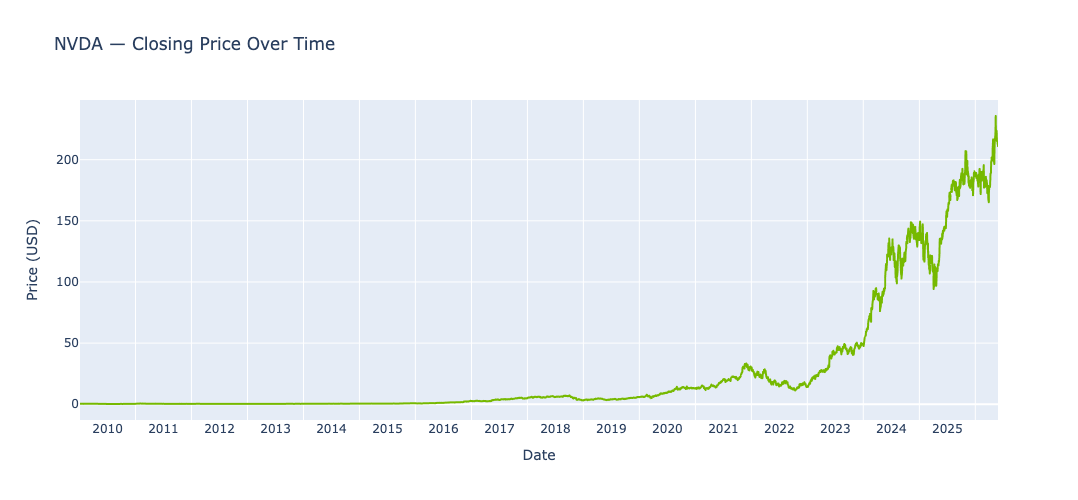

In [7]:
close = stock["Close"]["NVDA"]

fig = px.line(
    x=close.index,
    y=close.values,
    title="NVDA — Closing Price Over Time",
    labels={"x": "Date", "y": "Price (USD)"},
    width=1000,
    height=500,
)
fig.update_traces(line_color=NVDA_COLOR)
fig.update_xaxes(dtick="M12", tickformat="%Y", ticklabelmode="period")
fig.show()

It looks like a general upside trend. Around 2021 we can see a short slight downward direction until the end of 2022, this may be the effects of the Corona virus, the rapid rise in Interest Rates to fight Inflation and the beginning of the war in Ukraine, and a slightly bigger dip in 2025, caused by the release of Deepseek R1.

To take a closer look into the underlying structures, we are doing seasonal decomposition, which breaks the series into trend, seasonal, and residual components.

### Seasonal decomposition

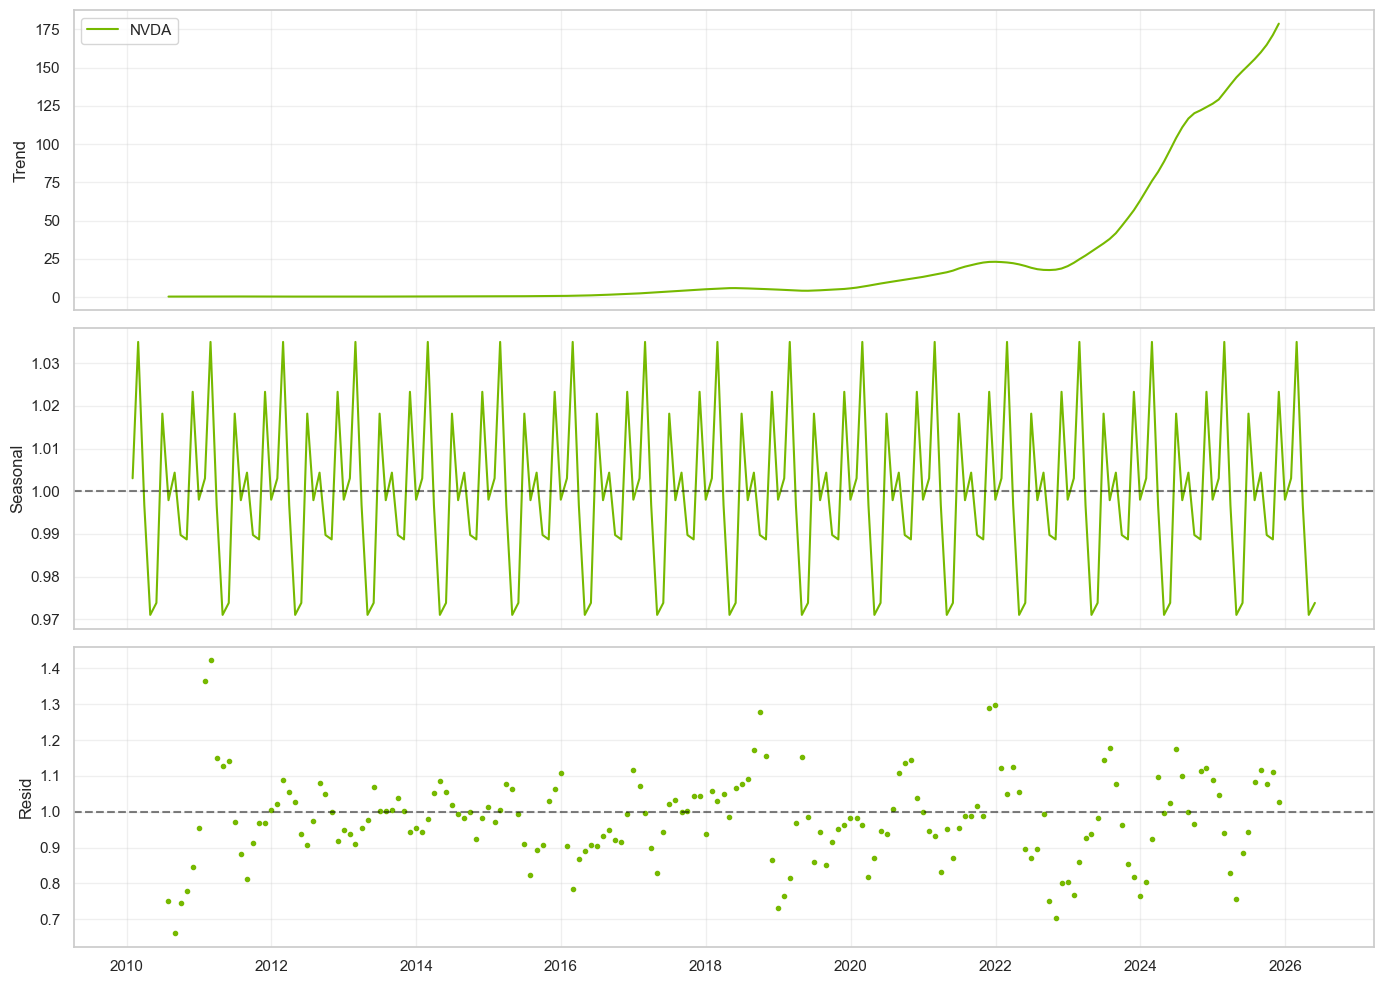

In [8]:
monthly = stock["Close"]["NVDA"].resample("ME").mean().dropna()
dec = seasonal_decompose(monthly, model="multiplicative", period=12)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dec.trend, color=NVDA_COLOR, label="NVDA")
axes[1].plot(dec.seasonal, color=NVDA_COLOR)
axes[2].plot(dec.resid.index, dec.resid, "o", markersize=3, color=NVDA_COLOR)

for ax, name in zip(axes, ["Trend", "Seasonal", "Resid"]):
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[1].axhline(1.0, color="black", linestyle="--", alpha=0.5)
axes[2].axhline(1.0, color="black", linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

The Trend panel highlights a decade of overall growth with a drastic increase from 2022 onwards.

The Seasonal section reveals that while the stock experiences predictable annual swings of roughly 
$\pm$3%. Finally, while the trend explains the long-term macro movements, the broadly dispersed points in the residual plot indicate that significant volatility remains. Rather than being tightly clustered, these residuals frequently fluctuate by up to 
$\pm$40%, illustrating that unpredictable market noise and sudden historical shocks, such as Nvidia earnings reporting, tech news, etc. consistently overpower the underlying seasonal patterns.

### Smoothing and Noise Reduction

Smoothing techniques help highlight long-term trends by reducing short-term fluctuations. We overlay 30-day and 90-day moving averages on each stock's Close — the 30-day tracks shorter-term momentum, the 90-day smooths over quarterly swings.

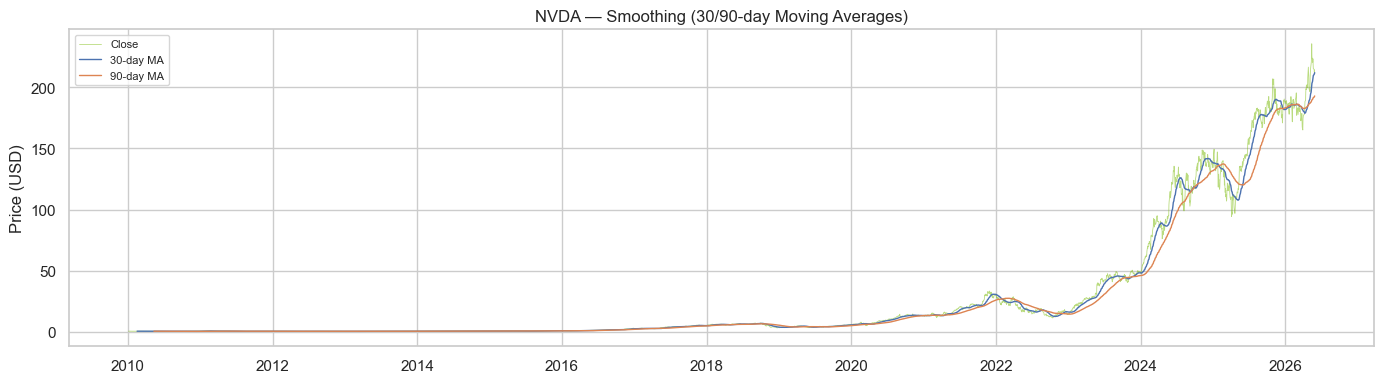

In [9]:
close = stock["Close"]["NVDA"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(close.index, close, label="Close", linewidth=0.6, alpha=0.5, color=NVDA_COLOR)
ax.plot(close.index, close.rolling(30).mean(), label="30-day MA", linewidth=1)
ax.plot(close.index, close.rolling(90).mean(), label="90-day MA", linewidth=1)
ax.set_title("NVDA — Smoothing (30/90-day Moving Averages)")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The 30-day moving average tracks short-term momentum and still wiggles with every few-week swing, while the 90-day MA smooths over roughly a quarter of trading and makes the broader direction easier to read. Both smoothed lines confirm what the raw plot already suggested: a decade long upward drift, with a drastic increase from 2022 onwards.

Short MA crossing below long MA (the so called "death cross") and back above (the so called "golden cross") are classic trend-shift signals: both are clearly visible in 2025, where the largest dip is followed by massive growth.

### Daily Returns

Another important thing we're going to look at is the daily returns. A stock's daily return is the percentual change in price over a single day. 

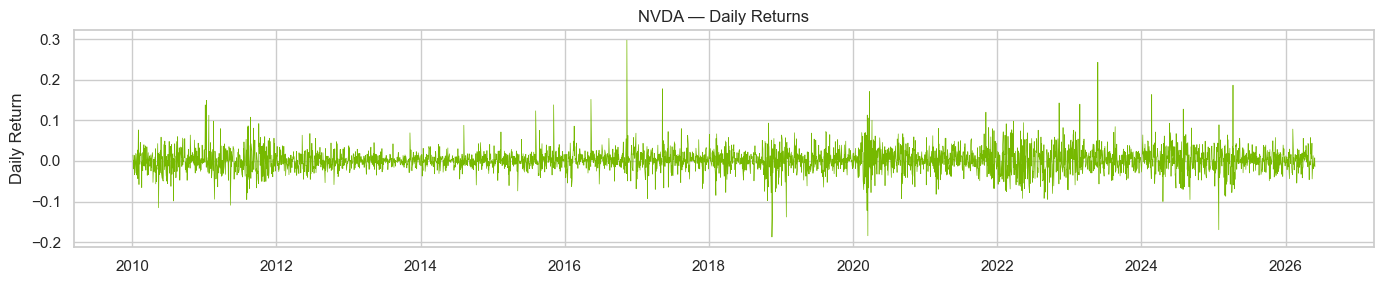

In [10]:
stock[("Daily_Return", "NVDA")] = stock["Close"]["NVDA"].pct_change()
returns = stock["Daily_Return"]["NVDA"]

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(returns.index, returns, linewidth=0.5, color=NVDA_COLOR)
ax.set_title("NVDA — Daily Returns")
ax.set_ylabel("Daily Return")
plt.tight_layout()
plt.show()

Daily returns hover around zero but with obvious volatility clustering.

Importantly, the series itself shows no visible trend — the mean level stays near zero throughout. That's exactly what the ADF test later confirms statistically: daily returns are stationary even though the underlying Close prices are not. 

### Distribution of Daily Returns

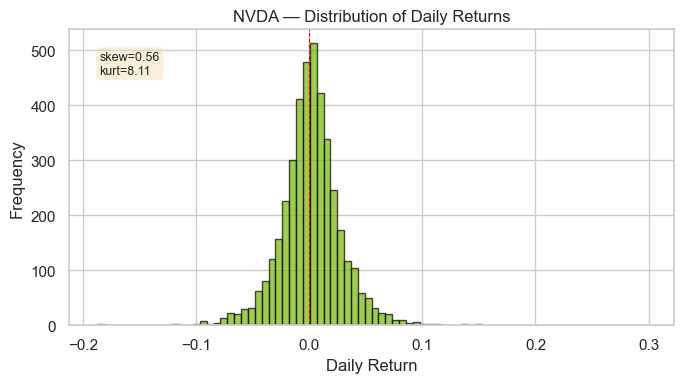

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(returns, bins=80, color=NVDA_COLOR, edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("NVDA — Distribution of Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

ax.annotate(
    f"skew={returns.skew():.2f}\nkurt={returns.kurtosis():.2f}",
    xy=(0.05, 0.85),
    xycoords="axes fraction",
    fontsize=9,
    bbox=dict(boxstyle="round", fc="wheat", alpha=0.5),
)

plt.tight_layout()
plt.show()

We see that the distribution is roughly bell-shaped and centered near zero, but with two systematic departures from normality.
It is slightly right skewed (skew=0.56) and has strong excess kurtosis (kurt=8.11), which means that the bell-curve approximation under-states the risk of extreme moves.

### Volatility

We are taking a look at the **rolling standard deviation of daily returns** since the level of return alone tells us nothing about risk — two periods can have the same average return but very different swings around it. Volatility captures exactly that, and is one of the most informative state features for the later regime clustering and RL agent.

We are looking at the monthly, quarterly and yearly rolling volatility. Hint: those are the active trading days.

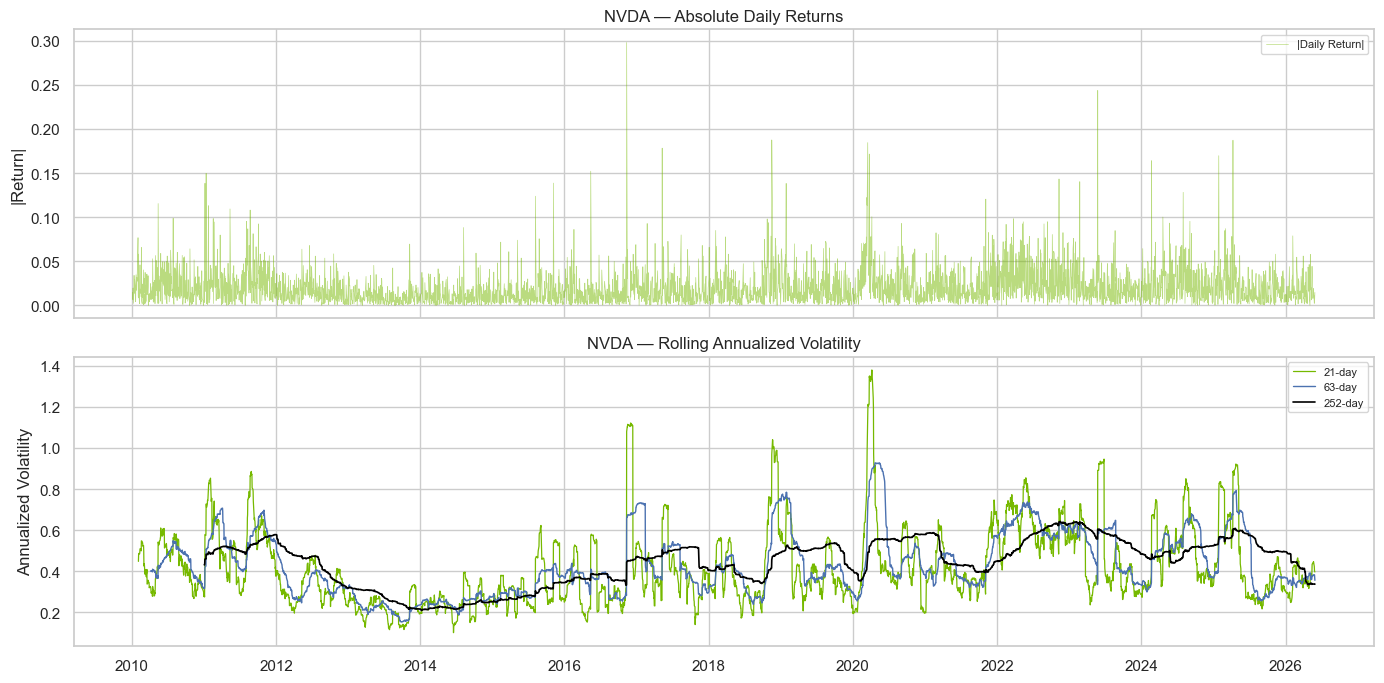

In [12]:
ann_vol_21 = returns.rolling(21).std() * np.sqrt(252)
ann_vol_63 = returns.rolling(63).std() * np.sqrt(252)
ann_vol_252 = returns.rolling(252).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(
    returns.index,
    returns.abs(),
    linewidth=0.5,
    color=NVDA_COLOR,
    alpha=0.5,
    label="|Daily Return|",
)
axes[0].set_ylabel("|Return|")
axes[0].set_title("NVDA — Absolute Daily Returns")
axes[0].legend(fontsize=8)

axes[1].plot(ann_vol_21.index, ann_vol_21, label="21-day", linewidth=0.9, color=NVDA_COLOR)
axes[1].plot(ann_vol_63.index, ann_vol_63, label="63-day", linewidth=1.0)
axes[1].plot(ann_vol_252.index, ann_vol_252, label="252-day", linewidth=1.2, color="black")
axes[1].set_ylabel("Annualized Volatility")
axes[1].set_title("NVDA — Rolling Annualized Volatility")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

NVDA's volatility is generaly pretty high, swings widely, and comes in clusters. The short (21-day) line shows when things turn turbulent (shocks like COVID 2020), while the long (252-day) line captures the structural risk level. The gap between them reveals regime shifts.

So including rolling volatility into our features may be a good idea, as well as considering some feature which is monthly and some which is yearly oriented.

### Stationarity

We are statistically testing what we observed above using the Augmented Dickey-Fuller (ADF) test.

In [13]:
p_close = adfuller(stock["Close"]["NVDA"].dropna())[1]
p_ret = adfuller(stock["Daily_Return"]["NVDA"].dropna())[1]
print(f"NVDA:  Close p={p_close:.3f}; Daily Returns p={p_ret:.2f}")

NVDA:  Close p=0.999; Daily Returns p=0.00


Statistically shown what we observed above: Close prices are **non stationary** (far above 0.05, so we fail to reject H0), while daily returns (p ~ 0) indeed are **stationary**.

## Unsupervised Learning

We dealing with years of historical prices or multiple indicators, at thousands of data points, leading to a problem known as the curse of dimensionality.

This makes it tough for machine learning models to pick out the signals from the noise.
By reducing the number of features while keeping the most critical information, this ensures your model stays efficient and accurate, without getting overwhelmed by irrelevant data.

Our goal in this section is to compress the daily NVDA state into a small, dense representation that the RL agent can later consume as part of its state vector.

We introduce the following features differentiating between nvidia internal and the market direction, measured by the sp500.

1. log daily return of NVDA
2. monthly rolling mean of the daily log return measuring momentum
3. monthly rolling std of the daily log return measuring volatility
4. daily range relative to price measuring volatility within a day
5. distance from the monthly moving average measuring short-term trend position
6. drawdown from the 1-year high measuring how far below the yearly peak we are
7. log daily return of the S&P 500
8. monthly rolling std of the S&P 500 daily return measuring market volatility
9. excess return measuring outperformance vs. the market, essentially relating nvidia to the market

### Feature engineering

In [14]:
close = stock["Close"]["NVDA"]
high = stock["High"]["NVDA"]
low = stock["Low"]["NVDA"]

sp500 = yf.download("^GSPC", start=start_date, end=end_date, progress=False)["Close"]
if isinstance(sp500, pd.DataFrame):
    sp500 = sp500.iloc[:, 0]

log_ret = np.log(close / close.shift(1))
sp500_ret = np.log(sp500 / sp500.shift(1)).reindex(close.index)

features = pd.DataFrame(index=close.index)
features["log_return"] = log_ret
features["mom_21"] = log_ret.rolling(21).mean()
features["vol_21"] = log_ret.rolling(21).std()
features["range_pct"] = (high - low) / close
features["sma_ratio"] = close / close.rolling(21).mean() - 1
features["drawdown_252"] = close / close.rolling(252).max() - 1
features["sp500_return"] = sp500_ret
features["sp500_vol_21"] = sp500_ret.rolling(21).std()
features["excess_return"] = log_ret - sp500_ret

features = features.dropna()
print(features.shape)
features.head()

(3875, 9)


,log_return,mom_21,vol_21,range_pct,sma_ratio,drawdown_252,sp500_return,sp500_vol_21,excess_return
Date,,,,,,,,,
2010-12-31,0.026984,0.003830,0.017361,0.028571,0.042990,-0.184322,-0.000191,0.003732,0.027175
2011-01-03,0.026908,0.004545,0.018007,0.029709,0.066483,-0.162076,0.011251,0.003527,0.015656
2011-01-04,-0.003166,0.003055,0.017237,0.031706,0.059778,-0.164725,-0.001314,0.003592,-0.001852
2011-01-05,0.073927,0.007486,0.022429,0.064782,0.132143,-0.084636,0.004995,0.003589,0.068932
2011-01-06,0.129622,0.012140,0.034590,0.101914,0.271272,0.000000,-0.002125,0.003689,0.131747


### Train/val/test split and Standardization

We split the data chronologically into three parts: **80 % train, 10 % validation, 10 % test** before fitting anything. The scaler, PCA, and autoencoder are all fitted on the train split only. The validation set is used solely to compare PCA vs. autoencoder reconstruction quality and pick the best representation. The test set is never touched until the final RL evaluation.

In [15]:
n = len(features)
split_train = int(n * 0.80)
split_val = int(n * 0.90)

features_train = features.iloc[:split_train]
features_val = features.iloc[split_train:split_val]
features_test = features.iloc[split_val:]

scaler = StandardScaler().fit(features_train.values)
X_train = scaler.transform(features_train.values)
X_val = scaler.transform(features_val.values)
X_test = scaler.transform(features_test.values)

print(
    f"Train: {features_train.index.min().date()} to {features_train.index.max().date()}  ({len(X_train)} days)"
)
print(
    f"Val:   {features_val.index.min().date()} to {features_val.index.max().date()}  ({len(X_val)} days)"
)
print(
    f"Test:  {features_test.index.min().date()} to {features_test.index.max().date()}  ({len(X_test)} days)"
)

X_df = pd.DataFrame(X_train, index=features_train.index, columns=features.columns)
X_df.describe().round(2).T[["mean", "std", "min", "max"]]

Train: 2010-12-31 to 2023-04-26  (3100 days)
Val:   2023-04-27 to 2024-11-07  (387 days)
Test:  2024-11-08 to 2026-05-29  (388 days)


,mean,std,min,max
log_return,-0.0,1.0,-7.44,9.23
mom_21,0.0,1.0,-3.89,3.76
vol_21,0.0,1.0,-1.59,5.20
range_pct,-0.0,1.0,-1.37,7.49
sma_ratio,-0.0,1.0,-4.24,5.84
drawdown_252,-0.0,1.0,-2.93,0.93
sp500_return,-0.0,1.0,-11.42,7.97
sp500_vol_21,0.0,1.0,-1.16,8.36
excess_return,-0.0,1.0,-9.33,11.55


All features are now on a common scale (zero mean, unit variance). This is essential for both PCA (which is variance-driven and would otherwise be dominated by features with naturally larger ranges) and for the autoencoder (which trains far more stably on normalized inputs).

### PCA

We start with PCA as a baseline: it is among the fastest and simplest dimensionality-reduction techniques, but it can only capture linear 
relationships.

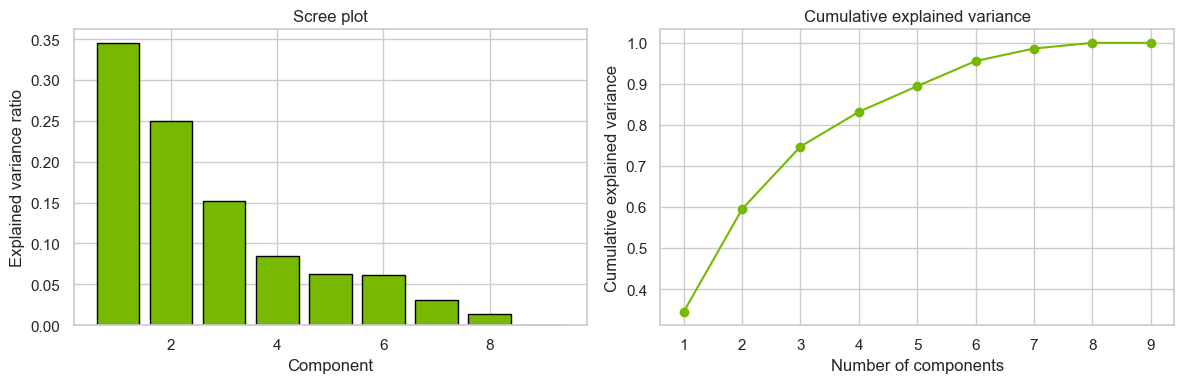

In [16]:
pca_full = PCA().fit(X_train)
explained = pca_full.explained_variance_ratio_
cum = explained.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(
    range(1, len(explained) + 1), explained, color=NVDA_COLOR, edgecolor="black"
)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(cum) + 1), cum, marker="o", color=NVDA_COLOR)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")

plt.tight_layout()
plt.show()

The first 2 components capture ~60% of the variance, 4 components reach ~85%, and 6 components ~95%.

Variance here means the total spread of the data, how far the data points lie apart. "Capturing 60%" means that projecting the 9 features onto just the first two components preserves 60% of that spread: the high-variance directions are exactly the ones along which data points are well separated, so two components are enough for a rough picture but still leave ~40% out.

After ~6 components the curve flattens, meaning additional components mostly carry redundant information. This confirms the intuition that the 9-feature set has a low intrinsic dimension.

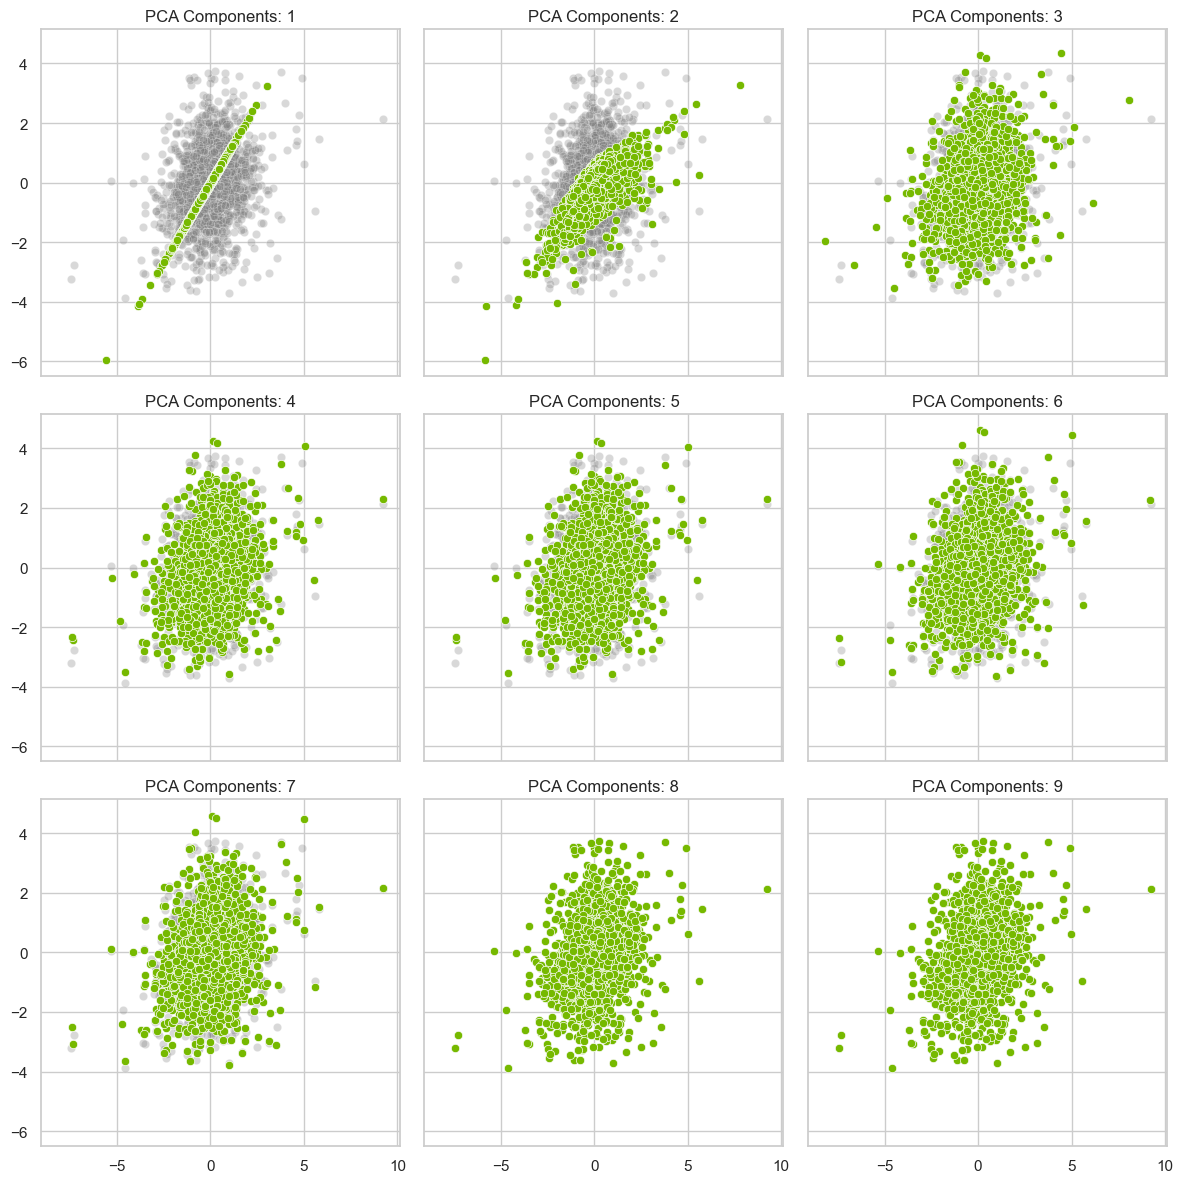

In [17]:
def transform_pca(X, n):
    pca = PCA(n_components=n)
    pca.fit(X)
    return pca.inverse_transform(pca.transform(X))


rows, cols = 3, 3
comps = 1

fig, axes = plt.subplots(rows, cols, figsize=(12, 12), sharex=True, sharey=True)

for row in range(rows):
    for col in range(cols):
        X_new = transform_pca(X_train, comps)
        ax = axes[row, col]
        sns.scatterplot(
            x=X_train[:, 0], y=X_train[:, 1], ax=ax, color="grey", alpha=0.3
        )
        sns.scatterplot(x=X_new[:, 0], y=X_new[:, 1], ax=ax, color=NVDA_COLOR)
        ax.set_title(f"PCA Components: {comps}")
        comps += 1

plt.tight_layout()
plt.show()

In our plot, the gray data is the original data, and the green points are the Principal Components. With just one component displayed, it takes the form of a set of points projected on a line that goes is along the axis with the most variance in the original data. As more and more components are added, we can see how the data starts to resemble the original data even though there is less information being displayed. By the time we get into the upper values, the data starts to match the original data where finally, at all 9 components, it is the same as the original.

Now we are taking a look at the loadings, first to read off which original features define each principal component, then to confirm that reading visually in the latent-space plots below.

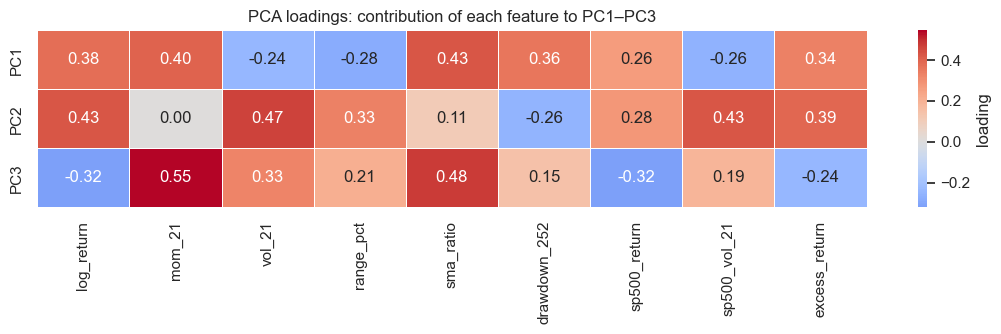

In [18]:
pca3 = PCA(n_components=3).fit(X_train)
Z_pca = pca3.transform(X_train)

loadings = pd.DataFrame(
    pca3.components_,
    index=["PC1", "PC2", "PC3"],
    columns=features.columns,
)

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "loading"},
    ax=ax,
)
ax.set_title("PCA loadings: contribution of each feature to PC1–PC3")
plt.tight_layout()
plt.show()

**PC1** the distance from the monthly moving average measuring short-term trend position (sma_ratio, 0.43) and momentum (mom_21, 0.40) seem to be the most important ones, meaning **PC1 is essentially a trend axis**, all the directional features: sma_ratio, mom_21, log_return, drawdown_252 and excess_return load positively, while the volatility features (vol_21, range_pct, sp500_vol_21) load negatively. The opposite signs tell a coherent story: a high PC1 score describes a calm market rising near its yearly high, a low score a falling, turbulent one. PC1 therefore separates *quiet uptrends from stressed downtrends*, the single most important regime direction.

**PC2** is dominated by vol_21 (0.47), log_return and sp500_vol_21 (both 0.43), while mom_21 drops to 0.00. It measures *how much is moving*, the magnitude of **volatility** and activity, independently of the trend direction.

**PC3** is led by mom_21 (0.55, the single largest loading in the matrix) and sma_ratio (0.48), with log_return and sp500_return negative (−0.32). It isolates NVDA's own sustained **momentum** from short-term daily and market-wide moves.

Together the three axes capture trend, volatility and momentum, exactly the kind of regime information we want to hand to the RL agent.

Finally we take a closer look at them by visualizing them.

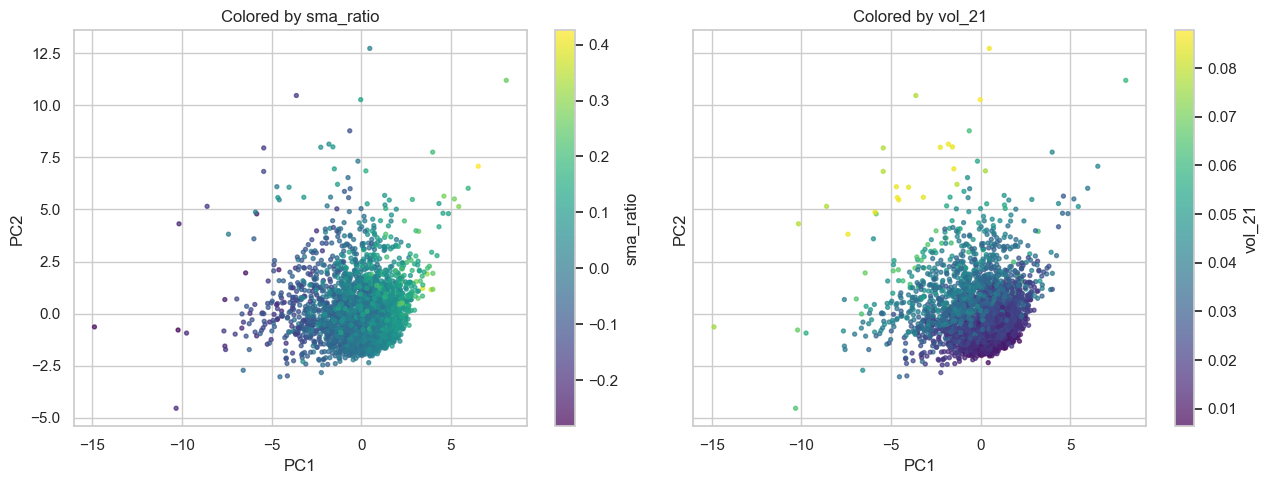

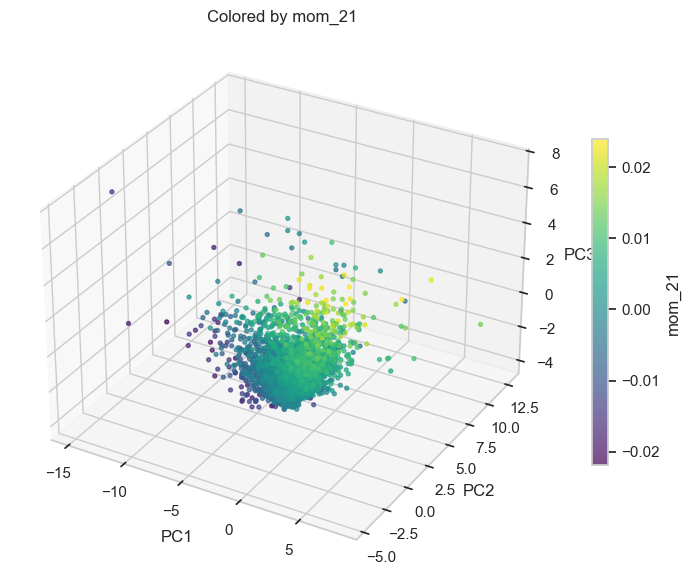

In [19]:
color_features = ["sma_ratio", "vol_21"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, feat in zip(axes, color_features):
    sc = ax.scatter(
        Z_pca[:, 0],
        Z_pca[:, 1],
        c=features_train[feat],
        cmap="viridis",
        s=8,
        alpha=0.7,
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Colored by {feat}")
    fig.colorbar(sc, ax=ax, label=feat)
fig.tight_layout()

fig_3d = plt.figure(figsize=(8, 6))
ax = fig_3d.add_subplot(111, projection="3d")
sc = ax.scatter(
    Z_pca[:, 0],
    Z_pca[:, 1],
    Z_pca[:, 2],
    c=features_train["mom_21"],
    cmap="viridis",
    s=8,
    alpha=0.7,
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Colored by mom_21")
fig_3d.colorbar(sc, ax=ax, label="mom_21", shrink=0.6)
fig_3d.tight_layout()
plt.show()

As the loadings predicted, the colors split into two roughly orthogonal gradients: distance from the monthly moving average measuring short-term trend position along PC1 (horizontal) and monthly rolling std of the daily log return measuring volatility along PC2 (vertical), so the axes capture trend and volatility as two independent regime directions. The 3D view adds NVDA's own momentum (mom_21) along PC3.

### Autoencoder

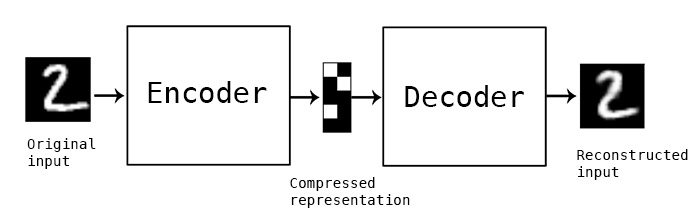

Now we try a more sophisticated, non-linear method: an autoencoder. It is a small neural network (a simple MLP) trained to reconstruct its own input after squeezing it through a narrow bottleneck layer. Since the bottleneck has fewer neurons than the input, the network is forced to learn a compact code that keeps only the information needed to rebuild the data, and that code is our latent representation.

Autoencoders are most commonly illustrated on image data, like the MNIST digits in the picture above, where each handwritten digit is encoded into a e.g. 2D latent point and then reconstructed. But the technique is general and works on any numeric data: here we apply the exact same encode-and-reconstruct idea to our 9 stock-market features instead of pixels.

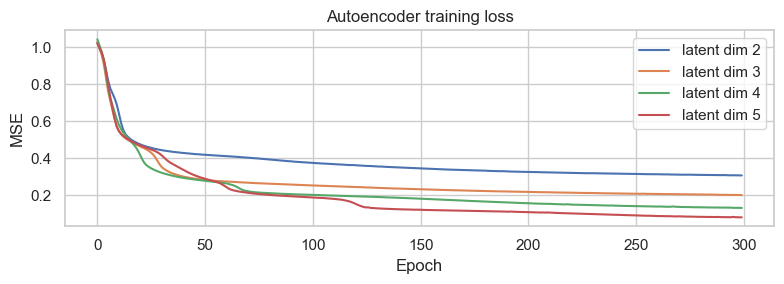

In [20]:
ae2, losses2 = train_autoencoder(X_train, 2)
ae3, losses3 = train_autoencoder(X_train, 3)
ae4, losses4 = train_autoencoder(X_train, 4)
ae5, losses5 = train_autoencoder(X_train, 5)

plt.figure(figsize=(8, 3))
plt.plot(losses2, label="latent dim 2")
plt.plot(losses3, label="latent dim 3")
plt.plot(losses4, label="latent dim 4")
plt.plot(losses5, label="latent dim 5")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Autoencoder training loss")
plt.legend()
plt.tight_layout()
plt.show()

All four autoencoders converge smoothly within a few hundred epochs. As expected, a larger bottleneck achieves a lower final reconstruction loss. The 3D curve sits in a good middle ground: it trains stably and converges to a noticeably lower loss than 2D.

Unlike PCA, an autoencoder has no components: its axes are nonlinear combinations of the inputs, so there are no loadings to read off. The equivalent check is to correlate each learned dimension with the original features: a high correlation means that dimension has captured that feature. We then confirm the picture visually, the same way we did for PCA.

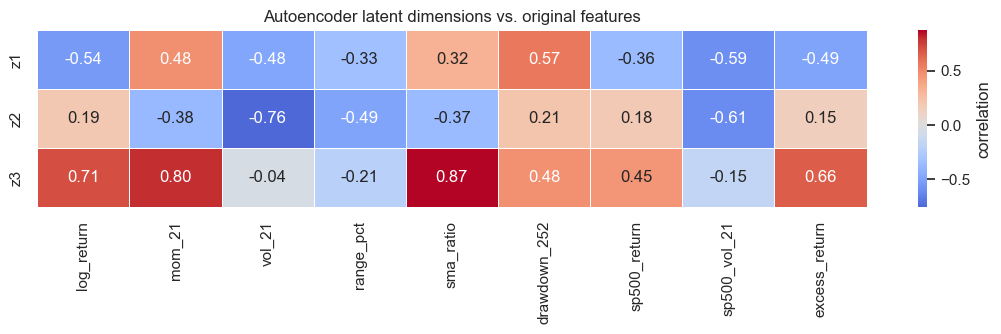

In [21]:
Z3 = encode(ae3, X_train)

ae_corr = pd.DataFrame(
    {
        f"z{i + 1}": [
            np.corrcoef(Z3[:, i], features_train[c])[0, 1] for c in features.columns
        ]
        for i in range(3)
    },
    index=features.columns,
).T

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(
    ae_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "correlation"},
    ax=ax,
)
ax.set_title("Autoencoder latent dimensions vs. original features")
plt.tight_layout()
plt.show()

The three learned dimensions map onto recognisable regime concepts, though less cleanly separated than the PCA components:

- **z3: trend/momentum**, the cleanest axis, with sma_ratio (0.87), mom_21 (0.80), log_return (0.71) and excess_return (0.66) loading together.
- **z2: volatility**, vol_21 (−0.76), sp500_vol_21 (−0.61) and range_pct (−0.49), hence the magnitude of market activity.
- **z1: market stress**, a more mixed direction combining market volatility (sp500_vol_21), the distance from the yearly high (drawdown_252) and the recent return (log_return).

We confirm this visually below. Plotting the two cleanest axes: z3 (trend) on the x-axis against z2 (volatility) on the y-axis and coloring by the matching feature should reproduce the same orthogonal-gradient pattern we saw for PCA. The 3D view adds the market-stress axis z1.

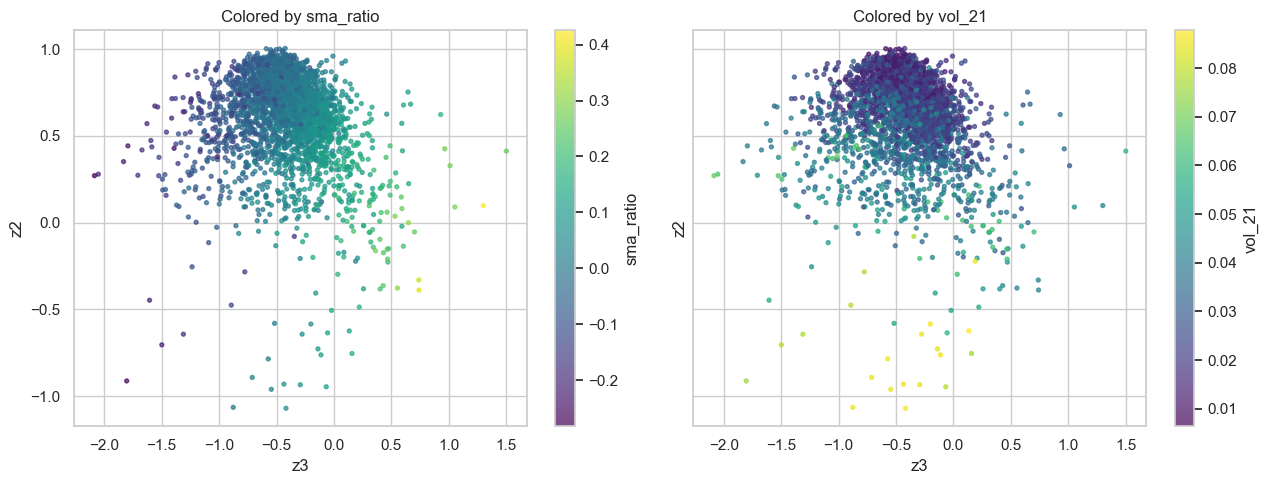

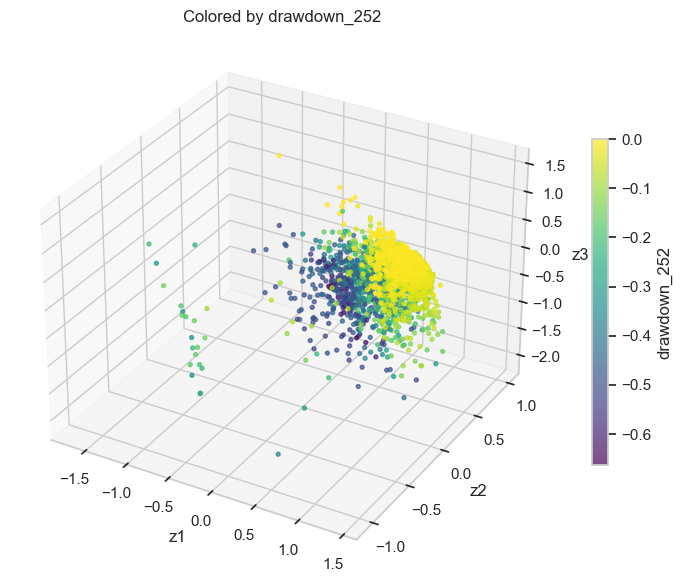

In [22]:
color_features = ["sma_ratio", "vol_21"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, feat in zip(axes, color_features):
    sc = ax.scatter(
        Z3[:, 2],
        Z3[:, 1],
        c=features_train[feat],
        cmap="viridis",
        s=8,
        alpha=0.7,
    )
    ax.set_xlabel("z3")
    ax.set_ylabel("z2")
    ax.set_title(f"Colored by {feat}")
    fig.colorbar(sc, ax=ax, label=feat)
fig.tight_layout()

fig_3d = plt.figure(figsize=(8, 6))
ax = fig_3d.add_subplot(111, projection="3d")
sc = ax.scatter(
    Z3[:, 0],
    Z3[:, 1],
    Z3[:, 2],
    c=features_train["drawdown_252"],
    cmap="viridis",
    s=8,
    alpha=0.7,
)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_zlabel("z3")
ax.set_title("Colored by drawdown_252")
fig_3d.colorbar(sc, ax=ax, label="drawdown_252", shrink=0.6)
fig_3d.tight_layout()
plt.show()

As the correlations predicted, coloring by sma_ratio produces a gradient along z3 (trend) while vol_21 varies along z2 (volatility): two roughly orthogonal regime directions, exactly as in the PCA projection. The 3D view shows the market-stress axis z1, picked out here by drawdown_252. So the autoencoder's latent space encodes the same interpretable regimes as PCA, which is what makes it a sensible state representation for the RL agent.

In [23]:
def pca_val_mse(k):
    p = PCA(n_components=k).fit(X_train)
    rec = p.inverse_transform(p.transform(X_val))
    return ((rec - X_val) ** 2).mean()


for k in (2, 3, 4, 5):
    print(f"PCA  {k}D val reconstruction MSE: {pca_val_mse(k):.4f}")
print()
for k, ae in zip((2, 3, 4, 5), (ae2, ae3, ae4, ae5)):
    print(f"AE   {k}D val reconstruction MSE: {reconstruction_mse(ae, X_val):.4f}")

PCA  2D val reconstruction MSE: 0.4265
PCA  3D val reconstruction MSE: 0.2205
PCA  4D val reconstruction MSE: 0.1523
PCA  5D val reconstruction MSE: 0.0812

AE   2D val reconstruction MSE: 0.2979
AE   3D val reconstruction MSE: 0.1781
AE   4D val reconstruction MSE: 0.1225
AE   5D val reconstruction MSE: 0.0711


### Summary

Both PCA and the autoencoder compress the 9 daily NVDA features into a compact representation that separates market regimes. The validation-set reconstruction MSE shows the autoencoder outperforms PCA.

We therefore use the **3D autoencoder** as our state encoder: it offers the best accuracy-compactness trade-off and produces a 4-dimensional RL state (3 latent features + previous position) that is small enough for a fast, simple policy network.

## Reinforcement Learning

Our action is discrete: {-1 = short, 0 = hold, +1 = long}\
and the reward follows: $r_t^{\text{net}} = a_{t-1} \cdot \text{return}_t \;-\; \text{cost} \cdot |a_t - a_{t-1}|$

We are using a simple PPO (Proximal Policy Optimization) approach. PPO is a policy-gradient method with an actor-critic setup: the **actor** outputs a probability distribution over the three actions, while the **critic** estimates the expected future reward of each state and serves as the baseline for the advantage. You can find the corresponding implementation in the ppo folder of the project root.

### State features for the environment

As observed above, the 3D autoencoder reconstructed the validation set better than PCA at the same size, so we use its latent code (ae3) as the state, one compact 3D vector per day. The environment appends the agent's previous position to each observation, and the reward uses the *simple* daily NVDA return.

In [24]:
ae = ae3
z_train = encode(ae, X_train)
z_test = encode(ae, X_test)

daily_return = stock["Daily_Return"]["NVDA"]
ret_train = daily_return.reindex(features_train.index).to_numpy(dtype="float32")
ret_test = daily_return.reindex(features_test.index).to_numpy(dtype="float32")

print(f"State features (train): {z_train.shape}")
print(f"State features (test):  {z_test.shape}")

State features (train): (3100, 3)
State features (test):  (388, 3)


### Training the PPO agent

We train PPO only on the training split, so the test period stays untouched for evaluation. Each episode covers one trading year (252 days) and starts on a random day of the training period, this way the agent sees many different market phases instead of always replaying the same sequence. Every change of position costs 10 basis points (0.1% of the traded amount) in transaction fees. Training runs silently: each iteration's metrics are stored in model.history and plotted below.

In [25]:
env_train = NVDATradingEnv(
    z_train, ret_train, cost=0.001, max_steps=252, random_start=True
)

hyperparams = {
    "timesteps_per_batch": 2048,
    "max_timesteps_per_episode": 252,
    "gamma": 0.99,
    "n_updates_per_iteration": 10,
    "lr": 3e-4,
    "clip": 0.2,
    "entropy_coef": 0.01,
    "render": False,
    "save_freq": 1_000_000,
    "seed": 0,
}

model = PPO(FeedForwardNN, env_train, **hyperparams)
model.learn(total_timesteps=1_000_000)

print(f"Trained {len(model.history['iteration'])} iterations.")

Successfully set seed to 0
Trained 441 iterations.


### Training curves

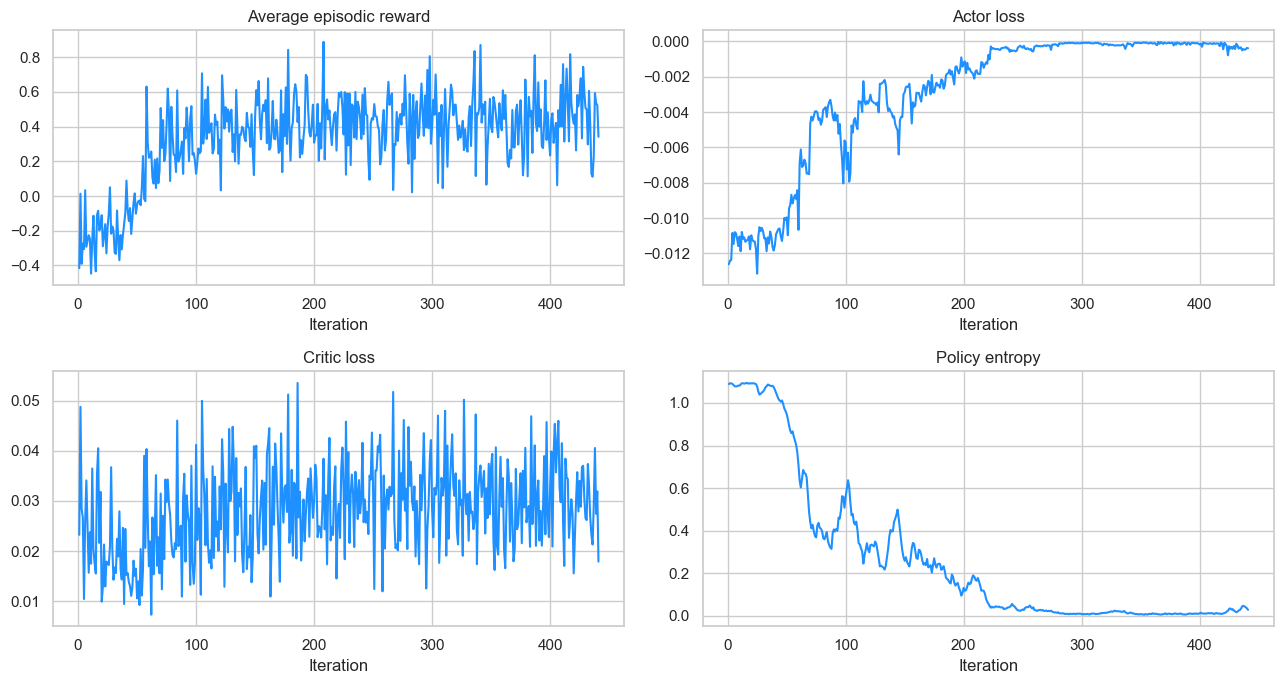

In [26]:
h = model.history
it = h["iteration"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].plot(it, h["avg_ep_rew"], color="#1E90FF")
axes[0, 0].set_title("Average episodic reward")

axes[0, 1].plot(it, h["actor_loss"], color="#1E90FF")
axes[0, 1].set_title("Actor loss")

axes[1, 0].plot(it, h["critic_loss"], color="#1E90FF")
axes[1, 0].set_title("Critic loss")

axes[1, 1].plot(it, h["entropy"], color="#1E90FF")
axes[1, 1].set_title("Policy entropy")

for ax in axes.flat:
    ax.set_xlabel("Iteration")

plt.tight_layout()
plt.show()

The **average episodic reward** climbs over the first ~80 iterations and then plateaus: this is the metric to watch, since it directly reflects how well the policy actually performs. A rising curve that flattens is the convergence pattern we want.

The **actor loss** is *not* a quality metric in PPO: it is the negative of a clipped surrogate objective, so a rising or noisy curve alongside a stable reward simply means the policy is hitting the clip threshold, not that training is failing.

The **critic loss** measures how well the value head predicts the discounted rewards-to-go. It doesn't have to drop monotonically since the critic chases a moving target as the policy shifts: a stable, non-exploding curve is what we want.

The **policy entropy** decreases smoothly from its random-initialization peak as the agent commits to specific actions. A gradual decline like this is healthy, a sudden collapse to near-zero would signal premature exploitation and lost exploration.

### Evaluation

**Primary:** cumulative PnL vs. buy-and-hold. **Secondary:** average return, max drawdown, hit ratio, turnover.

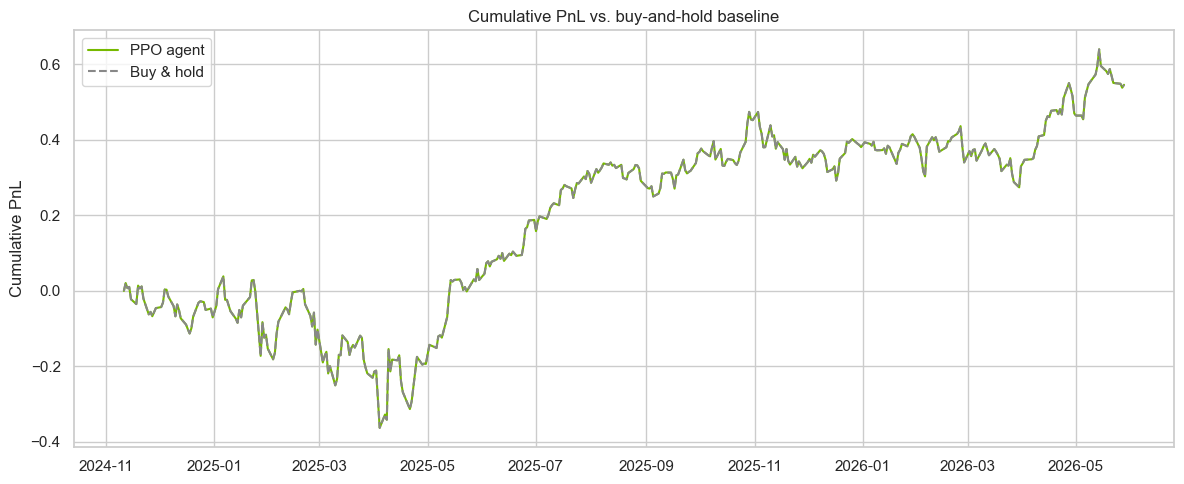

In [27]:
env_test = NVDATradingEnv(
    z_test, ret_test, cost=0.001, max_steps=len(z_test) - 2, random_start=False
)

with torch.no_grad():
    pos_agent, rew_agent = evaluate(env_test, lambda o: int(model.actor(o).argmax()))
_, rew_bh = evaluate(env_test, lambda o: 2)

pnl_agent, pnl_bh = rew_agent.cumsum(), rew_bh.cumsum()
dates = features_test.index[1 : 1 + len(pnl_agent)]

plt.figure(figsize=(12, 5))
plt.plot(dates, pnl_agent, color=NVDA_COLOR, label="PPO agent")
plt.plot(dates, pnl_bh, color="#888888", linestyle="--", label="Buy & hold")
plt.title("Cumulative PnL vs. buy-and-hold baseline")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
print(f"Cumulative PnL agent: {pnl_agent[-1]:+.4f} vs. buy & hold: {pnl_bh[-1]:+.4f}")
print(f"Average return: {rew_agent.mean():+.5f}")
print(f"Max drawdown: {(pnl_agent - np.maximum.accumulate(pnl_agent)).min():.4f}")
print(f"Hit ratio: {(rew_agent > 0).mean():.2%}")
print(f"Turnover: {np.abs(np.diff(pos_agent, prepend=0)).mean():.4f}")

Cumulative PnL agent: +0.5450 vs. buy & hold: +0.5450
Average return: +0.00141
Max drawdown: -0.4015
Hit ratio: 52.85%
Turnover: 0.0026


## Results

The agent's cumulative PnL (**+0.5450**) exactly matches buy-and-hold (**+0.5450**) over the 388-day test window: the agent has learned to simply stay long the entire time.

The **turnover of 0.0026** confirms this: the agent essentially never changes its position. This is a somewhat expected failure mode on a strongly bull-trending stock like NVDA: on the training period (2010–2023, an almost uninterrupted uptrend) the reward-maximising policy is to hold long, and the agent collapses onto it. The **hit ratio of 52.85 %** is barely above random, and the **max drawdown of −40.2 %** is NVDA's own drawdown: the agent rode the full dip down to ~$94 in April 2025 and the recovery back up, never stepping aside, exactly because it stays long.

I also tested other state features, such as PCA, but none of those outperformed our buy-and-hold baseline.

## Limitations and Improvements

- trying non-policy gradient based methods
- improving the feature engineering part
- reduce or generally adapt action space, since nvidias stock is basically only increasing, hence hold or staying long is most of the time the best and for sure the safest option
- adapting the reward function to be risk-adjusted